<a href="https://colab.research.google.com/github/KaustubhSN12/TSA_Fitted_Curve/blob/main/TSA_ratio_trend_%26_MA_Practical_5_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 5.	Measurement of Seasonal indices Ratio-to-Trend method  using python

/tmp/ipykernel_879/947458544.py:8: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  "Month": pd.date_range(start="2020-01-01", periods=36, freq="M"),


Seasonal Indices (Ratio-to-Trend Method):
Month_Only
1     0.769651
2     0.829347
3     0.937595
4     1.008606
5     1.133787
6     1.203948
7     1.255915
8     1.143805
9     1.032254
10    0.957401
11    0.882920
12    0.844770
Name: Ratio, dtype: float64


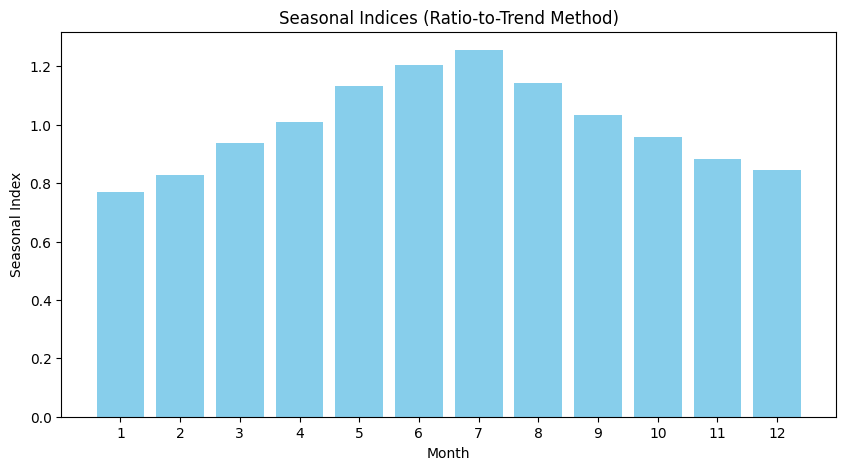

In [1]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

# Sample time series data (e.g., monthly sales data for 3 years)
data = {
    "Month": pd.date_range(start="2020-01-01", periods=36, freq="M"),
    "Sales": [200, 220, 250, 270, 300, 320, 340, 310, 280, 260, 240, 230,
              210, 225, 255, 275, 310, 330, 345, 315, 285, 265, 245, 235,
              215, 230, 260, 280, 320, 340, 350, 320, 290, 270, 250, 240]
}

df = pd.DataFrame(data)
df["Month_Num"] = np.arange(1, len(df) + 1)  # Create a time index

# Step 1: Fit a Linear Trend Model (Sales = a + b*Time)
X = sm.add_constant(df["Month_Num"])  # Add constant for intercept
model = sm.OLS(df["Sales"], X).fit()
df["Trend"] = model.predict(X)

# Step 2: Calculate the Ratio-to-Trend (Sales / Trend)
df["Ratio"] = df["Sales"] / df["Trend"]

# Step 3: Compute Average Seasonal Indices
df["Month_Only"] = df["Month"].dt.month  # Extract month number
seasonal_indices = df.groupby("Month_Only")["Ratio"].mean()

# Normalize the indices to sum up to the number of periods (12 for monthly data)
seasonal_indices = seasonal_indices / seasonal_indices.mean()

# Display the seasonal indices
print("Seasonal Indices (Ratio-to-Trend Method):")
print(seasonal_indices)

# Step 4: Plot the Seasonal Indices
plt.figure(figsize=(10, 5))
plt.bar(seasonal_indices.index, seasonal_indices.values, color='skyblue')
plt.xlabel("Month")
plt.ylabel("Seasonal Index")
plt.title("Seasonal Indices (Ratio-to-Trend Method)")
plt.xticks(range(1, 13))
plt.show()


# 6.	Measurement of Seasonal indices Ratio-to-Moving Average method  using

1.   List item
2.   List item

python




**Data Preparation:**

A sample dataset with monthly sales data is created.


**Centered Moving Average (CMA):**

This smooths the trend using a rolling mean.


**Ratio-to-Moving Average (RMA):**

The ratio of actual sales to CMA is calculated.


**Grouping by Season (Month):**

The average RMA for each month is computed.


**Normalization:**

The indices are adjusted so their sum equals 12 (since we have 12 months).

In [2]:
import numpy as np
import pandas as pd

# Sample Data: Monthly Sales Data
data = {
    'Month': pd.date_range(start='2020-01', periods=24, freq='M'),  # 2 years of data
    'Sales': [260, 280, 300, 320, 310, 330, 360, 380, 400, 420, 410, 430,
              270, 290, 310, 330, 320, 340, 370, 390, 410, 430, 420, 440]
}

df = pd.DataFrame(data)
df['Month_Num'] = df['Month'].dt.month  # Extract month number

# 1. Calculate Centered Moving Average (12-month moving average for monthly data)
df['CMA'] = df['Sales'].rolling(window=12, center=True).mean()

# 2. Compute Ratio-to-Moving Average (Sales / CMA)
df['RMA'] = df['Sales'] / df['CMA']

# 3. Compute Seasonal Indices (Average of RMA for each month)
seasonal_indices = df.groupby('Month_Num')['RMA'].mean()

# 4. Normalize the Seasonal Indices (so they sum to the number of seasons)
seasonal_indices = seasonal_indices / seasonal_indices.mean() * 12

# Display Seasonal Indices
print("Seasonal Indices:\n", seasonal_indices)


Seasonal Indices:
 Month_Num
1      9.109921
2      9.761815
3     10.410663
4     11.056486
5     10.696507
6     11.338670
7     12.315331
8     12.973643
9     13.624105
10    14.271492
11    13.898837
12    14.542530
Name: RMA, dtype: float64


/tmp/ipykernel_879/3635051035.py:6: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  'Month': pd.date_range(start='2020-01', periods=24, freq='M'),  # 2 years of data
